In [122]:
from pathlib import Path
from scipy.io import loadmat

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import scipy
import seaborn as sns
import pynapple as nap
import cmap

def load_bin(
    filename: str | Path,
    n_channels: int,
    dtype: str = "int16",
):
    """Load binary data as a read-only memory-mapped array of shape: (n_samples, n_channels)."""
    return np.memmap(filename, dtype=dtype, mode="r").reshape(-1, n_channels)

f = r"R:\Basic_Sciences\Phys\SenzaiLab\Yuta_Senzai\UCSF_data\ProcessedData2\DataProcess\YutaTest107b\YutaTest107b.eeg"

### Load data

In [ ]:
import os 
import requests

fname = "Achilles_10252013_EEG.nwb"
path = Path('.tmp/') / fname

if not path.is_file():    
    r = requests.get(f"https://osf.io/2dfvp/download", stream=True)
    block_size = 1024 * 1024
    with open(path, "wb") as f:
        for data in r.iter_content(block_size):
            f.write(data)

In [158]:
data = nap.load_file(path)
fs = 1250
data

Achilles_10252013_EEG
┍━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys        │ Type        │
┝━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units       │ TsGroup     │
│ rem         │ IntervalSet │
│ nrem        │ IntervalSet │
│ forward_ep  │ IntervalSet │
│ eeg         │ TsdFrame    │
│ theta_phase │ Tsd         │
│ position    │ Tsd         │
┕━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙

### Analysis

In [159]:
lfp = data['eeg'][:, 0].restrict(data['rem'])
ca1 = data['units'].restrict(data['rem'])

ep_ex_rem = nap.IntervalSet(
    data["rem"]["start"][0] + 95.0,
    data["rem"]["start"][0] + 100.0,
)

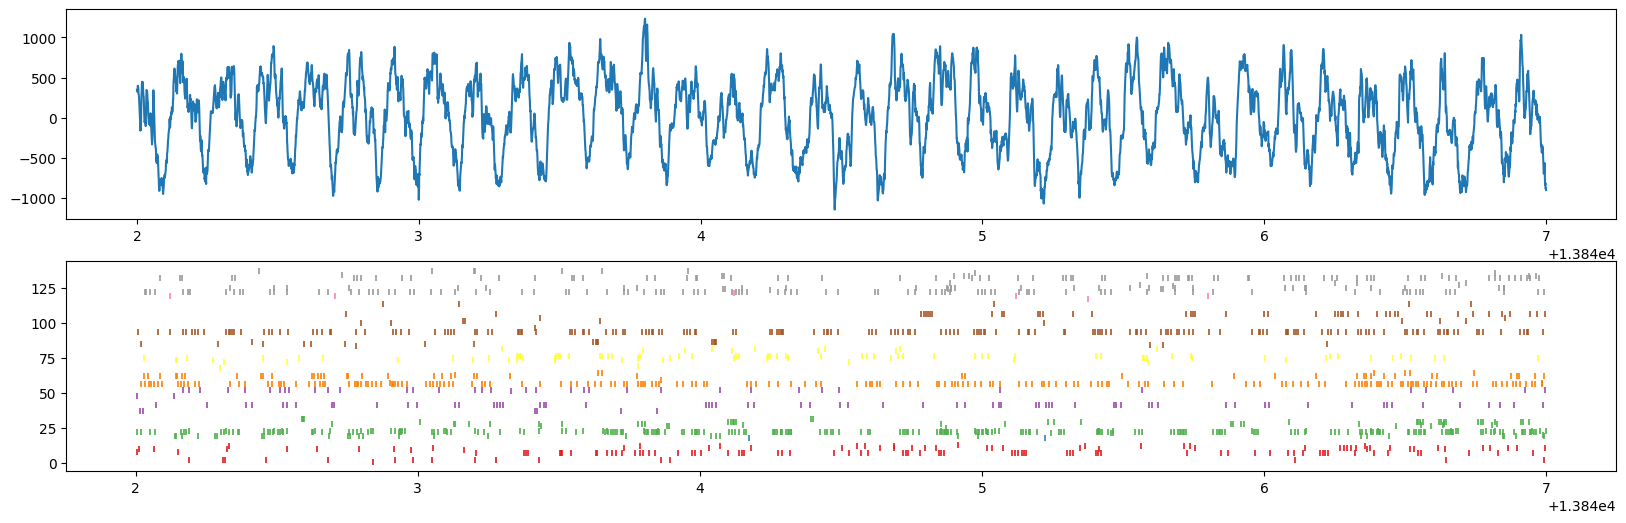

In [137]:
q_cmap = cmap.Colormap('colorbrewer:Set1').to_mpl()
spikes = ca1.restrict(ep_ex_rem)

plt.figure(figsize=(20, 6))
plt.subplot(211)
plt.plot(lfp.restrict(ep_ex_rem))
plt.subplot(212)
for row, (uid, ts) in enumerate(spikes.items(), start=1):
    plt.plot(
        ts.fillna(row),
        "|",
        color=q_cmap(spikes["shank"][uid] / 13),
        markersize=5,
        markeredgewidth=1.2,
    )

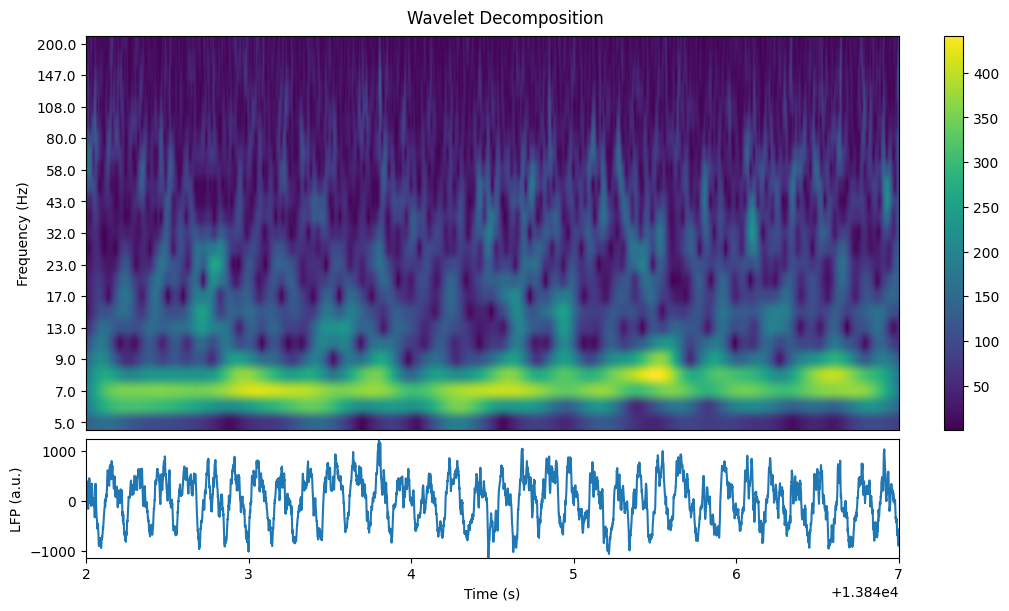

In [135]:
freqs = np.geomspace(5, 200, 25)
cwt_rem = nap.compute_wavelet_transform(lfp.restrict(ep_ex_rem), fs=fs, freqs=freqs)
# Define wavelet decomposition plotting function
def plot_timefrequency(freqs, powers, ax=None):
    im = ax.imshow(np.abs(powers), aspect="auto")
    ax.invert_yaxis()
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.get_xaxis().set_visible(False)
    ax.set(yticks=np.arange(len(freqs))[::2], yticklabels=np.rint(freqs[::2]))
    ax.grid(False)
    return im

fig = plt.figure(constrained_layout=True, figsize=(10, 6))
fig.suptitle("Wavelet Decomposition")
gs = plt.GridSpec(2, 1, figure=fig, height_ratios=[1.0, 0.3])

ax0 = plt.subplot(gs[0, 0])
im = plot_timefrequency(freqs, np.transpose(cwt_rem[:, :].values), ax=ax0)
cbar = fig.colorbar(im, ax=ax0, orientation="vertical")

ax1 = plt.subplot(gs[1, 0])
ax1.plot(lfp.restrict(ep_ex_rem))
ax1.set_ylabel("LFP (a.u.)")
ax1.set_xlabel("Time (s)")
ax1.margins(0)
plt.show()

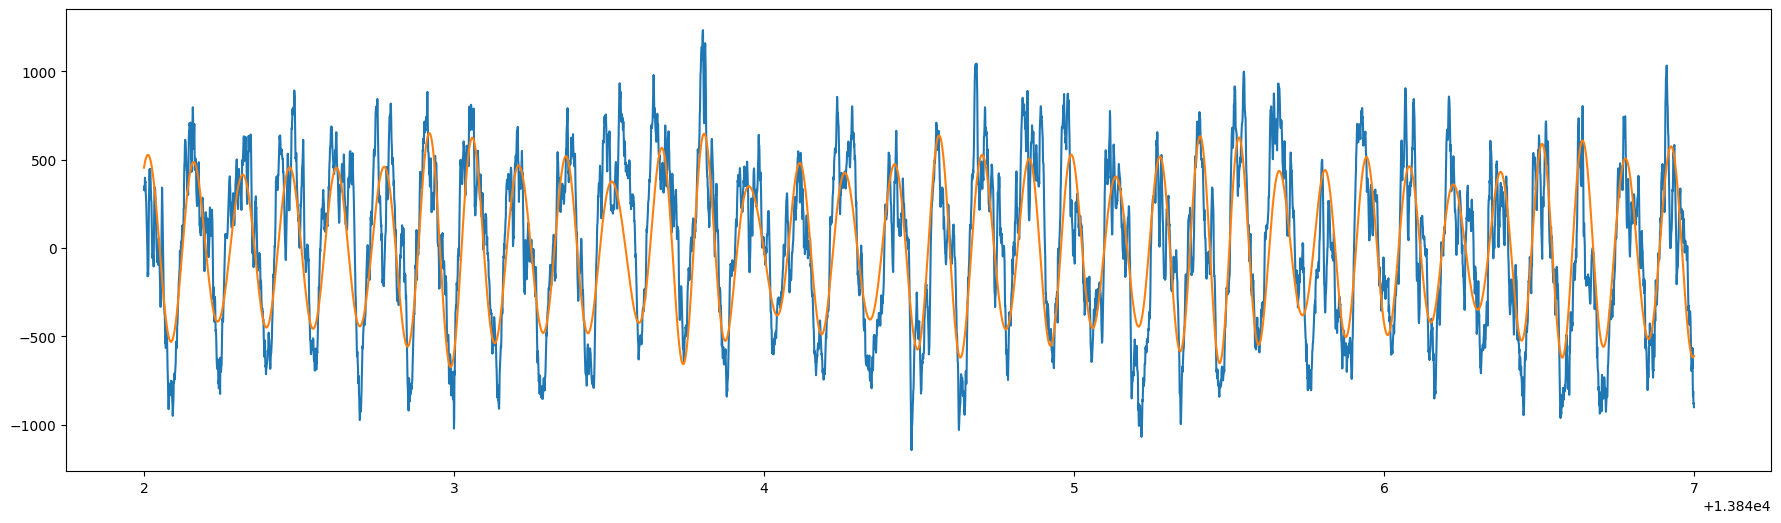

In [160]:
theta = nap.apply_bandpass_filter(lfp, cutoff=(6.0, 10.0), fs=fs)

plt.figure(figsize=(22, 6))
plt.plot(lfp.restrict(ep_ex_rem))
plt.plot(theta.restrict(ep_ex_rem))

In [161]:
theta_amplitude = nap.compute_hilbert_envelope(theta)
theta_phase = nap.compute_hilbert_phase(theta)

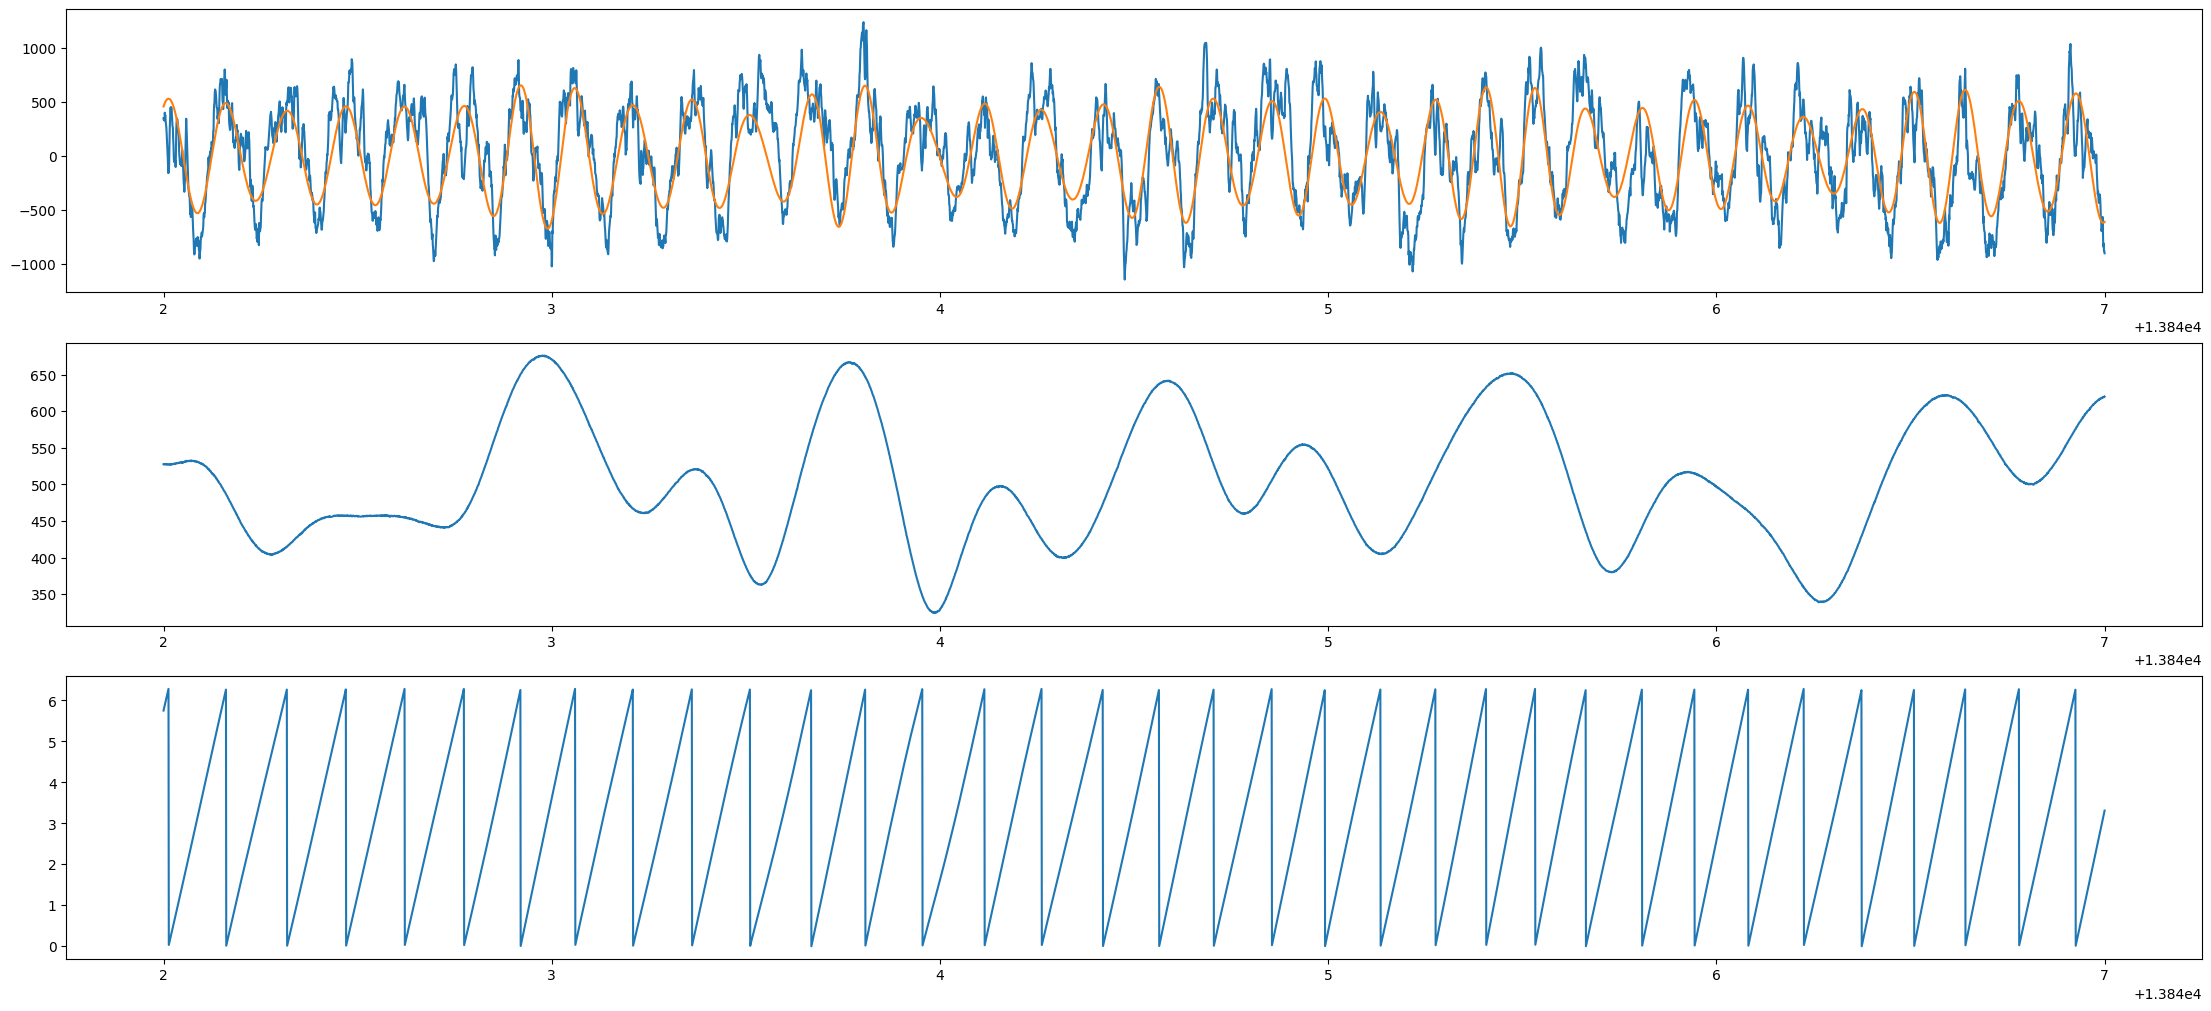

In [164]:
plt.figure(constrained_layout=True, figsize=(22, 10))

plt.subplot(311)
plt.plot(lfp.restrict(ep_ex_rem))
plt.plot(theta.restrict(ep_ex_rem))

plt.subplot(312)
plt.plot(theta_amplitude.restrict(ep_ex_rem))

plt.subplot(313)
plt.plot(theta_phase.restrict(ep_ex_rem))

In [165]:
spikes = ca1[ca1.rate > 5]

In [206]:
phase_modulation = nap.compute_tuning_curves(
    data=spikes, 
    features=theta_phase, 
    bins=61, 
    range=(0, 2*np.pi), 
    feature_names=["Phase"]
)

phase_modulation.name="Firing Rate"
phase_modulation.attrs["units"]="Hz"
phase_modulation.coords["Phase"].attrs["unit"]="rad"

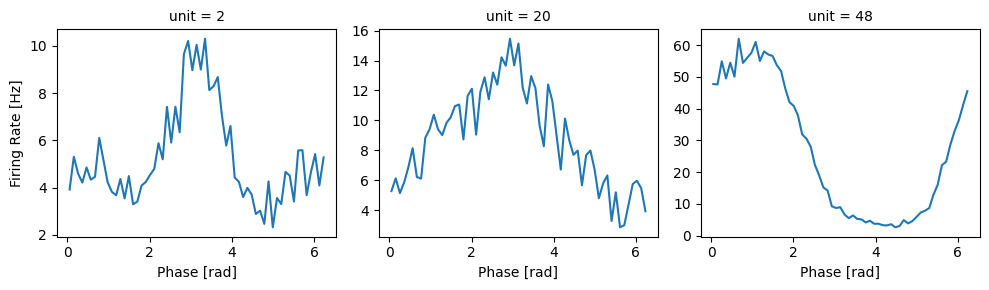

In [211]:
phase_modulation[:3].plot(row="unit", col_wrap=3, sharey=False)
plt.show()

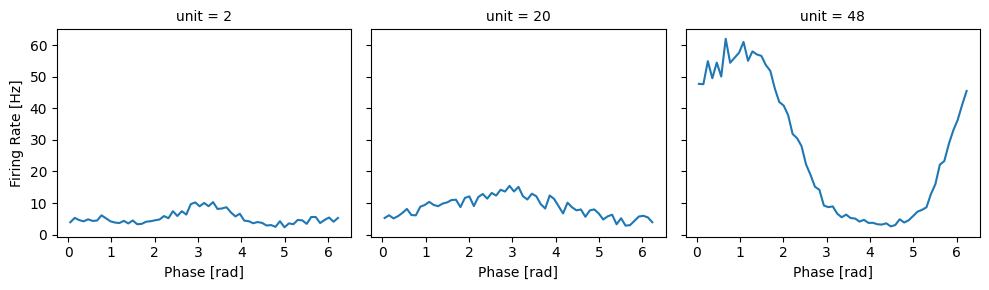

In [212]:
phase_modulation[:3].plot(row="unit", col_wrap=3, sharey=True)
plt.show()

In [208]:
spike_phase = spikes[spikes.index[3]].value_from(theta_phase)
spike_phase

Time (s)
-----------  --------
13747.0134   1.78386
13747.0197   2.11633
13747.264    0.274555
13747.29035  1.48419
13747.3108   2.40402
13747.42705  0.494355
13747.4801   1.52557
...
22572.5397   0.872567
22572.5738   2.4514
22572.67785  1.14111
22572.7421   4.25022
22572.8248   1.99904
22572.8359   2.52601
22572.92845  1.30002
dtype: float64, shape: (4752,)

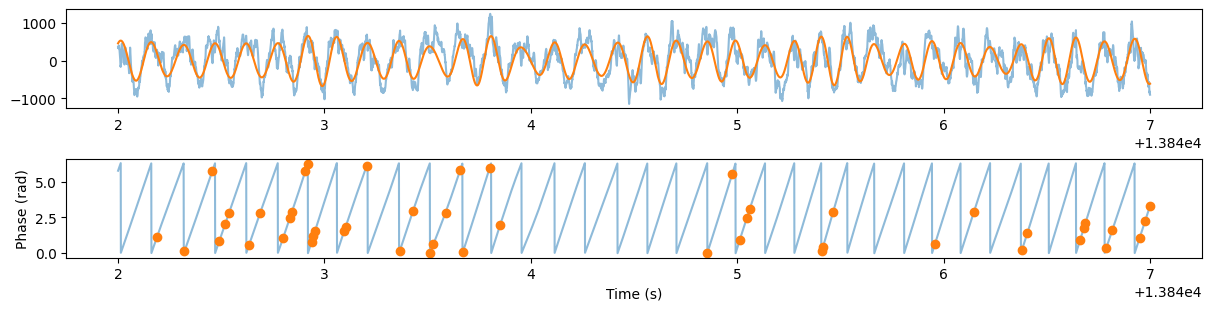

In [209]:
plt.figure(constrained_layout=True, figsize=(12, 3))
plt.subplot(211)
plt.plot(lfp.restrict(ep_ex_rem), alpha=0.5)
plt.plot(theta.restrict(ep_ex_rem))
plt.subplot(212)
plt.plot(theta_phase.restrict(ep_ex_rem), alpha=0.5)
plt.plot(spike_phase.restrict(ep_ex_rem), 'o')
plt.ylabel("Phase (rad)")
plt.xlabel("Time (s)")
plt.show()